In [13]:
import pandas as pd
from glob import glob
import json

In [14]:
working_dir = '/home/bl4zc/bi_bl4zc/variant-list-optimizer'
vl_files_path = f'{working_dir}/scratch_output/optimal-list-highs_size-10*.json'

In [15]:
variant_list_files = glob(vl_files_path)

# Read all JSON files
variant_lists_data = {}
for file_path in variant_list_files:
    with open(file_path, 'r') as f:
        variant_lists_data[file_path] = json.load(f)

# Show what was loaded
print(f"Loaded {len(variant_lists_data)} JSON files:")
# for file_path in variant_lists_data.keys():
#     print(f"  - {file_path}")

Loaded 193 JSON files:


In [16]:
import re
from pathlib import Path

# Process each JSON file
results = []
for file_path, data in variant_lists_data.items():
    # Extract date from filename (e.g., optimal-list-highs_2025-01-04.json -> 2025-01-04)
    filename = Path(file_path).name
    date_match = re.search(r'(\d{4}-\d{2}-\d{2})', filename)
    date = date_match.group(1) if date_match else "unknown"
    
    # Get variant list and format as comma-separated string (excluding empty strings)
    variant_list = data.get('variant_list', [])
    variant_string = ','.join([v for v in variant_list if v])  # Filter out empty strings
    
    results.append({
        'date': date,
        'file': filename,
        'variant_list': variant_string
    })

df = pd.DataFrame(results)
df.sample(5)

# Display results
# for result in results:
#     print(f"Date: {result['date']}")
#     print(f"File: {result['file']}")
#     print(f"Variants: {result['variant_list']}")
#     print()

,date,file,variant_list
26,2024-06-01,optimal-list-highs_size-10-end-date_2024-06-01...,"JN.1.11.1,BA.5.3.1,CH.1,JN.1,XBB.2.3,EG.5.1,GJ..."
171,2023-09-30,optimal-list-highs_size-10-end-date_2023-09-30...,"EG.5.1,XBB.1.5,B.1.1.529,XBB.1.9.1,BA.2.75,CH...."
17,2025-04-05,optimal-list-highs_size-10-end-date_2025-04-05...,"NB.1,KP.3.1.1,LB.1,KS.1.1.1,MB.1.1,LP.8.1,JN.1..."
155,2025-03-22,optimal-list-highs_size-10-end-date_2025-03-22...,"JN.1.16.1,EG.5,LB.1,JN.1,MB.1.1,KS.1.1.1,JN.1...."
68,2025-07-26,optimal-list-highs_size-10-end-date_2025-07-26...,"XFG,LP.8.1,LB.1,JN.1.11.1,BA.2.86,LF.7,KP.3.1...."


In [17]:
selected_sample = df.sample(1)
print(f"For end date: {selected_sample.date.values[0]} \noptimal list: {selected_sample.variant_list.values[0]}")

For end date: 2022-11-05 
optimal list: BA.2.75,BA.5.2.1,BA.5.2,BA.4.6,BA.5.3.1,BQ.1,BM.4.1.1,BA.5.1,B.1.1.529


In [18]:
### Most recent optimal list
print(f'Optimal list for {df.date.max()}:\n   {df[df.date == df.date.max()]["variant_list"].values[0]}')

Optimal list for 2026-02-21:
   XFG.3.4,JN.1.11.1,BA.2.86,PY.1.1,XDV.1.5.1,XFG,LP.8.1,LF.7,NB.1.8.1


In [24]:
df[df.date > '2026-01-15'].variant_list.values

<ArrowStringArray>
[  'XDV.1.5,XFG,JN.1.11.1,XFG.3.4,LP.8.1,LF.7,PY.1.1,BA.2.86,NB.1.8.1',
   'JN.1.11.1,XDV.1.5,LP.8.1,XFG,XFG.3.4,LF.7,NB.1.8.1,PY.1.1,BA.2.86',
     'BA.2.86,JN.1.11.1,XFG.3.4,NB.1.8.1,XFG,LP.8.1,PY.1,XDV.1.5,LF.7',
   'NB.1.8.1,XFG,JN.1.11.1,PY.1.1,XFG.3.4,XDV.1.5,BA.2.86,LF.7,LP.8.1',
   'XFG,XDV.1.5,JN.1.11.1,XFG.3.4,LF.7,NB.1.8.1,BA.2.86,PY.1.1,LP.8.1',
 'XFG.3.4,JN.1.11.1,BA.2.86,PY.1.1,XDV.1.5.1,XFG,LP.8.1,LF.7,NB.1.8.1']
Length: 6, dtype: str

In [20]:
df.to_csv(f'{working_dir}/scratch_output/variant_lists_size10_180days.csv', index=False)

In [23]:
df.variant_list.value_counts()

variant_list
KP.3.1.1,LP.8.1,LF.7,JN.1.11.1,MB.1,XFG,BA.2.86,NB.1.8,LB.1           1
BA.2.86,KP.3.1.1,LP.8.1,LB.1,NB.1.8,LF.7,JN.1.11.1,PY.1,XFG           1
JN.1.11.1,KP.1.1.3,KS.1.1,KP.3.1.1,JN.1,MB.1.1,JN.1.16.1,LB.1,EG.5    1
LB.1,XFG.3,JN.1.11.1,LF.7,NB.1.8.1,PY.1,XFG,LP.8.1,BA.2.86            1
FL.1.5,BA.5,GJ.1.2,CH.1,JN.1,XBB.2.3,EG.5.1,XBB.1,BA.2                1
                                                                     ..
XBB.1,XBB.2.3,XBB.1.9.1,JN.1,B.1.1.529,CH.1.1,HV.1,EG.5.1,BE.1.1.1    1
XBB.1,XBB.1.9,CH.1.1,JN.1.11,B.1.1.529,XBB.2.3,BQ.1,BA.2.75,BA.5      1
P.1,AY.44,B.1.1,AY.25,B.1,B.1.617.2,AY.3,AY.103,B.1.1.7               1
EG.5,LB.1,JN.1.16.1,KP.1.1,KP.3.1.1,JN.1.11.1,KS.1,MB.1.1,JN.1        1
KP.3.1.1,JN.1,JN.1.16.1,MB.1.1,KP.1.1,EG.5,JN.1.11.1,LB.1,KS.1        1
Name: count, Length: 193, dtype: int64

In [14]:
# Split the comma-delimited strings and expand into rows
expanded_data = []
for idx, row in df.iterrows():
    date = row['date']
    # Split the variant_list by comma and strip whitespace
    variants = [v.strip() for v in row['variant_list'].split(',') if v.strip()]
    for variant in variants:
        expanded_data.append({'date': date, 'variant': variant})

# Create new dataframe
variant_counts_df = pd.DataFrame(expanded_data)

# Count occurrences of each variant
variant_summary = variant_counts_df.groupby('variant').size().reset_index(name='count').sort_values('count', ascending=False)

print("Top variants:")
print(variant_summary.head(10))
print(f"\nTotal unique variants: {len(variant_summary)}")
print(f"\nExpanded dataframe shape: {variant_counts_df.shape}")
print(f"Columns: {variant_counts_df.columns.tolist()}")
print("\nFirst few rows:")
print(variant_counts_df.head())

Top variants:
      variant  count
0   B.1.1.529    108
29       JN.1    101
43   KP.3.1.1     67
65      XBB.1     62
32  JN.1.11.1     60
72    XBB.2.3     57
50       LB.1     53
15     EG.5.1     50
37     KP.1.1     49
58     MB.1.1     48

Total unique variants: 80

Expanded dataframe shape: (1694, 2)
Columns: ['date', 'variant']

First few rows:
         date  variant
0  2025-07-19  MC.10.1
1  2025-07-19   MB.1.1
2  2025-07-19   NB.1.8
3  2025-07-19   KS.1.1
4  2025-07-19      XFG


In [20]:
variant_counts_df


,date,variant
0,2025-07-19,MC.10.1
1,2025-07-19,MB.1.1
2,2025-07-19,NB.1.8
3,2025-07-19,KS.1.1
4,2025-07-19,XFG
...,...,...
1689,2025-08-30,NB.1.8.1
1690,2025-08-30,MC.10.1
1691,2025-08-30,JN.1.11.1
1692,2025-08-30,B.1.1.529


In [23]:
# Binary presence/absence matrix: rows=dates, columns=variants
presence_matrix = (
    variant_counts_df.assign(value=1)
    .pivot_table(index='date', columns='variant', values='value', aggfunc='max', fill_value=0)
    .sort_index()
)

presence_matrix.head()

variant,B.1.1.529,BA.2,BA.2.75,BA.2.75.3,BA.2.86.1,BA.5,BA.5.2,BA.5.3.1,BE.1.1,BE.1.1.1,...,XBB.1.9.1,XBB.1.9.2,XBB.2.3,XDV.1,XDV.1.5,XDV.1.5.1,XEC,XFG,XFG.3,XFG.3.4
date,,,,,,,,,,,,,,,,,,,,,
2023-06-03,1,0,1,0,0,1,1,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2023-06-10,1,0,1,0,0,1,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2023-06-17,1,0,1,0,0,1,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2023-06-24,1,0,1,0,0,1,1,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2023-07-01,1,0,1,0,0,1,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


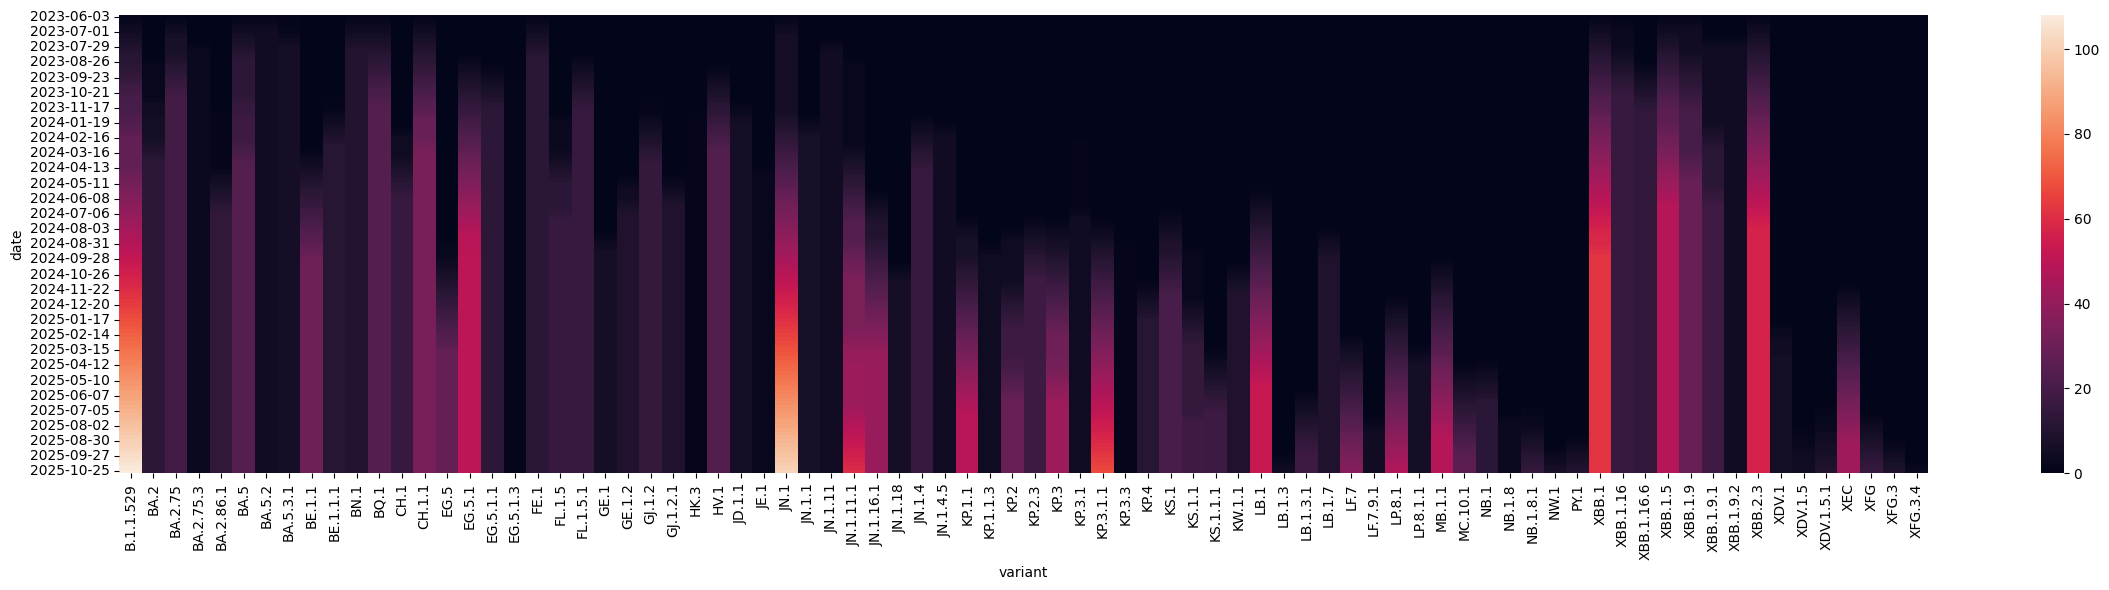

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make the figure wider so x-axis labels are visible
plt.figure(figsize=(24, 6))
sns.heatmap(presence_matrix.cumsum())
plt.tight_layout()

In [15]:
variant_counts_df.variant.value_counts().head(10)

variant
B.1.1.529    108
JN.1         101
KP.3.1.1      67
XBB.1         62
JN.1.11.1     60
XBB.2.3       57
LB.1          53
EG.5.1        50
KP.1.1        49
MB.1.1        48
Name: count, dtype: int64

In [ ]:
var

In [43]:
# Get first appearance date for each variant
first_appearance = variant_counts_df.groupby('variant')['date'].min().reset_index()
first_appearance.columns = ['variant', 'first_appearance_date']

# Merge with the expanded dataframe
variant_counts_df_with_first = variant_counts_df.merge(first_appearance, on='variant')

# Sort by variant and then by date
variant_counts_df_with_first = variant_counts_df_with_first.sort_values(['variant', 'date']).reset_index(drop=True)

print("Dataframe with first appearance date:")
print(variant_counts_df_with_first.head(15))
print(f"\nShape: {variant_counts_df_with_first.shape}")
print(f"Columns: {variant_counts_df_with_first.columns.tolist()}")

Dataframe with first appearance date:
          date variant first_appearance_date
0   2023-06-03     B.1            2023-06-03
1   2023-06-10     B.1            2023-06-03
2   2023-06-17     B.1            2023-06-03
3   2023-06-24     B.1            2023-06-03
4   2023-07-01     B.1            2023-06-03
5   2023-07-08     B.1            2023-06-03
6   2023-07-15     B.1            2023-06-03
7   2023-07-22     B.1            2023-06-03
8   2023-07-29     B.1            2023-06-03
9   2023-08-05     B.1            2023-06-03
10  2023-08-12     B.1            2023-06-03
11  2023-08-19     B.1            2023-06-03
12  2023-08-26     B.1            2023-06-03
13  2023-09-02     B.1            2023-06-03
14  2023-09-09     B.1            2023-06-03

Shape: (1694, 3)
Columns: ['date', 'variant', 'first_appearance_date']


In [44]:
# Create a simplified dataframe with just variant and first appearance date
variant_first_appearance = variant_counts_df_with_first[['variant', 'first_appearance_date']].drop_duplicates().sort_values('variant').reset_index(drop=True)

print(f"Unique variants with first appearance date:")
print(variant_first_appearance)
print(f"\nTotal unique variants: {len(variant_first_appearance)}")

Unique variants with first appearance date:
       variant first_appearance_date
0          B.1            2023-06-03
1    B.1.1.529            2023-06-03
2    B.1.617.2            2023-06-03
3         BA.2            2023-09-09
4      BA.2.75            2023-06-03
5    BA.2.86.1            2023-11-24
6         BA.5            2023-06-03
7       BA.5.2            2023-06-03
8     BA.5.3.1            2023-06-03
9     BE.1.4.2            2023-11-10
10        BQ.1            2023-06-03
11      CH.1.1            2023-06-03
12      EG.5.1            2023-08-12
13    EG.5.1.1            2023-09-02
14      FL.1.5            2024-01-05
15    FL.1.5.1            2023-08-19
16      GJ.1.2            2024-02-16
17     GK.1.11            2023-11-17
18        HV.1            2023-09-09
19      JD.1.1            2023-11-17
20        JN.1            2023-06-03
21      JN.1.1            2024-01-05
22   JN.1.11.1            2024-05-18
23   JN.1.16.1            2025-03-22
24      JN.1.4            2024-

## Raw data analysis

In [3]:
raw_df = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_2020-03-01_to_2021-12-31.csv')

/tmp/ipykernel_304087/1142292922.py:1: DtypeWarning: Columns (0: division, 1: fips) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_2020-03-01_to_2021-12-31.csv')


<Axes: xlabel='date'>

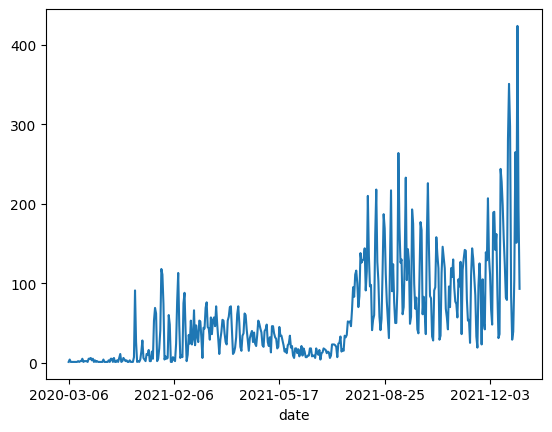

In [7]:
raw_df[raw_df.division == "Virginia"].groupby('date').lineage_count.sum().plot()


##  Combine individual cov-spectrum pulls

In [ ]:
# raw_df1 = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_2020-03-01_to_2021-12-31.csv')
# raw_df2 = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_2022-01-01_to_2024-12-31.csv')   
# raw_df3 = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_2025-01-01_to_2026-02-15.csv')   
# raw_df = pd.concat([raw_df1, raw_df2, raw_df3], ignore_index=True)

# print(f'raw_df1: {raw_df1.date.min()} to {raw_df1.date.max()} rows= {raw_df1.shape[0]},')
# print(f'raw_df2: {raw_df2.date.min()} to {raw_df2.date.max()} rows= {raw_df2.shape[0]},')
# print(f'raw_df3: {raw_df3.date.min()} to {raw_df3.date.max()} rows= {raw_df3.shape[0]}')
# print(f'raw_df:  {raw_df.date.min()} to {raw_df.date.max()} rows= {raw_df.shape[0]}')

# print(f'Sice of raw_df1: {raw_df1.shape}, raw_df2: {raw_df2.shape}, raw_df3: {raw_df3.shape}\nCombined raw_df: {raw_df2.shape}')


/tmp/ipykernel_304087/3986648427.py:1: DtypeWarning: Columns (0: division, 1: fips) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df1 = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_2020-03-01_to_2021-12-31.csv')
/tmp/ipykernel_304087/3986648427.py:2: DtypeWarning: Columns (0: division, 1: fips) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df2 = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_2022-01-01_to_2024-12-31.csv')


raw_df1: 2020-03-01 to 2021-12-31 rows= 284952,
raw_df2: 2022-01-01 to 2024-12-31 rows= 605528,
raw_df3: 2025-01-01 to 2026-01-25 rows= 56119
raw_df:  2020-03-01 to 2026-01-25 rows= 946599


In [ ]:
# raw_df.to_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_all-dates.csv', index=False   )

In [16]:
raw_df = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_all-dates.csv')
raw_df.sample()

/tmp/ipykernel_304087/2076385585.py:1: DtypeWarning: Columns (0: division, 1: fips) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/cov-spectrum_variants_states_long_all-dates.csv')


,lineage_count,date,lineage,division,fips,daily_frac,lineage_count_rolling,total_count,total_count_rolling,proportion,proportion_ci_lower,proportion_ci_upper
24234,1.0,2021-09-21,AY.5.3,California,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
raw_df[(raw_df.division == "Virginia") &
       (raw_df.date >= "2021-02-14") & 
       (raw_df.date <= "2021-02-21")].lineage.value_counts()

lineage
B.1.2        8
B.1.243      6
B.1.427      6
B.1.1.7      5
B.1.351      5
B.1          4
B.1.429      4
P.2          4
R.1          4
B.1.1.207    3
B.1.1.519    3
B.1.311      3
B.1.1        2
B.1.234      2
B.1.240      2
B.1.265      2
B.1.409      2
B.1.575      2
B.1.637      2
B.1.1.348    1
B.1.1.434    1
B.1.214.2    1
B.1.404      1
B.1.517      1
B.1.525      1
B.1.526      1
B.1.551      1
B.1.561      1
B.1.577      1
B.1.605      1
B.1.609      1
N.5          1
Name: count, dtype: int64

In [20]:
oi_df = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/outbreak_info_variants_states_long.csv')
oi_df.sample()

/tmp/ipykernel_304087/528726122.py:1: DtypeWarning: Columns (0: division, 1: fips) have mixed types. Specify dtype option on import or set low_memory=False.
  oi_df = pd.read_csv(f'bi_bl4zc/variant-list-optimizer/data/outbreak_info_variants_states_long.csv')


,lineage_count,date,lineage,division,fips,daily_frac,lineage_count_rolling,total_count,total_count_rolling,proportion,proportion_ci_lower,proportion_ci_upper
829424,3,2022-12-21,BF.5,NaN,US,0.001406,3.714286,2134.0,2118.285714,0.001753,0.000567,0.004284


In [25]:
oi_df[(oi_df.division == "Virginia") &
       (oi_df.date >= "2021-02-14") & 
       (oi_df.date <= "2021-02-21")].lineage.value_counts()

lineage
B.1.2        8
B.1.243      6
B.1.427      6
B.1.1.7      5
B.1.351      5
B.1          4
B.1.429      4
P.2          4
R.1          4
B.1.1.207    3
B.1.1.519    3
B.1.311      3
B.1.1        2
B.1.234      2
B.1.240      2
B.1.265      2
B.1.409      2
B.1.575      2
B.1.637      2
B.1.1.348    1
B.1.1.434    1
B.1.214.2    1
B.1.404      1
B.1.517      1
B.1.525      1
B.1.526      1
B.1.551      1
B.1.561      1
B.1.577      1
B.1.605      1
B.1.609      1
N.5          1
Name: count, dtype: int64